In [1]:
import pandas as pd

# Đọc dữ liệu từ file sales.csv đưa vào biến df (dataframe - bảng dữ liệu)
df = pd.read_csv('sales.csv')

# Hiển thị 5 dòng đầu tiên để xem mặt mũi dữ liệu ra sao
df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


thấy được cột như mã giao dịch (sale_id), chi nhánh (branch), thành phố (city), loại khách hàng (customer_type), giới tính (gender), và tên sản phẩm (product_name).

In [2]:
# Xem tổng quan số dòng, số cột và tình trạng dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB


1000 entries (1000 dòng): Tương đương với 1000 hóa đơn mua hàng đã được ghi nhận.

12 columns (12 cột): Mỗi hóa đơn chứa 12 trường thông tin (ví dụ: thành phố, giới tính khách hàng, tên sản phẩm, giá tiền, v.v.).

1000 non-null:Dòng này báo cho ta biết cả 12 cột đều chứa đủ 1000 dòng dữ liệu, không có bất kỳ một ô nào bị bỏ trống hay thiếu sót.

,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


Nhìn vào cột total_price ở hàng max, ta có thể thấy: Hóa đơn có giá trị lớn nhất mà công ty bán được trị giá 433.99 (giả sử đơn vị là USD).

Không chỉ vậy, nếu nhìn vào hàng mean (giá trị trung bình) của cột total_price,ta sẽ thấy con số 118.58. ta gọi đây là AOV (Average Order Value - Giá trị trung bình trên mỗi đơn hàng)

In [4]:
# Tính tổng doanh thu theo từng nhóm sản phẩm và sắp xếp từ lớn đến bé
revenue_by_product = df.groupby('product_category')['total_price'].sum().sort_values(ascending=False)

# In kết quả ra màn hình
print("TỔNG DOANH THU THEO TỪNG NHÓM SẢN PHẨM:")
print(revenue_by_product)

TỔNG DOANH THU THEO TỪNG NHÓM SẢN PHẨM:
product_category
Personal Care    27050.18
Fruits           26197.45
Beverages        22983.32
Household        21615.84
Stationery       20737.11
Name: total_price, dtype: float64


từ trên ta có thể thấy tổng doanh thu của từng sãng phẫm theo từng loại, và ta thấy Personal Care có doanh thu cao nhất

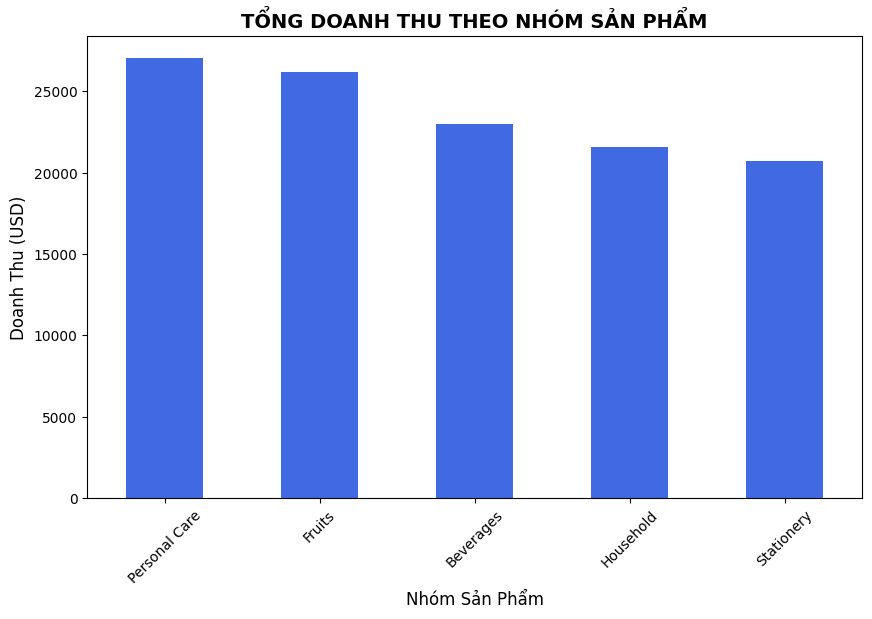

In [5]:
import matplotlib.pyplot as plt

# Thiết lập kích thước khung hình biểu đồ cho to và rõ nét
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột với dữ liệu đã tính toán ở bước trước
revenue_by_product.plot(kind='bar', color='royalblue')

# Thêm tiêu đề và chú thích cho các trục để sếp dễ đọc
plt.title('TỔNG DOANH THU THEO NHÓM SẢN PHẨM', fontsize=14, fontweight='bold')
plt.ylabel('Doanh Thu (USD)', fontsize=12)
plt.xlabel('Nhóm Sản Phẩm', fontsize=12)

# Xoay chữ ở trục ngang 45 độ để các tên sản phẩm không bị đè lên nhau
plt.xticks(rotation=45)

# Lệnh hiển thị biểu đồ ra màn hình
plt.show()

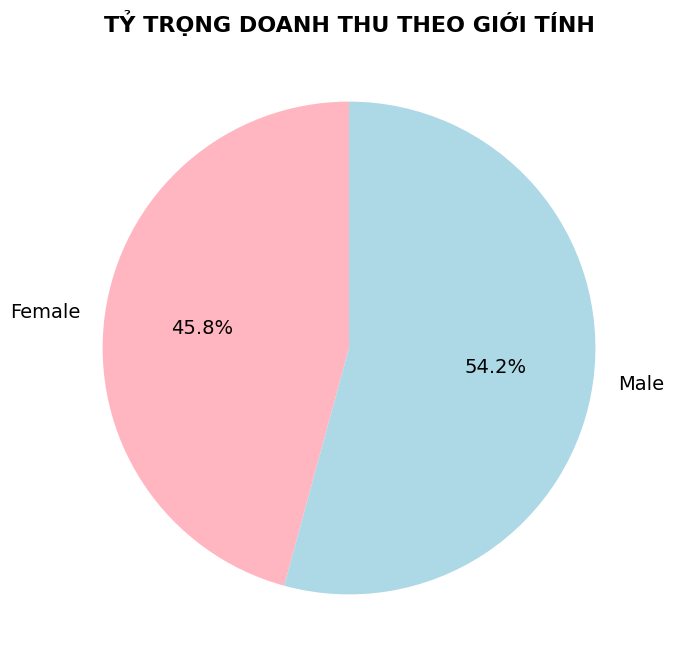

In [6]:
# 1. Tính tổng doanh thu theo từng giới tính (Gender)
revenue_by_gender = df.groupby('gender')['total_price'].sum()

# 2. Thiết lập kích thước biểu đồ
plt.figure(figsize=(8, 8))

# 3. Vẽ biểu đồ tròn (Pie chart)
# autopct='%1.1f%%': Lệnh này tự động tính và hiển thị phần trăm (%) lên biểu đồ
# colors: Chọn màu hồng (lightpink) cho Nữ và xanh dương (lightblue) cho Nam
revenue_by_gender.plot(kind='pie', autopct='%1.1f%%', colors=['lightpink', 'lightblue'], startangle=90, textprops={'fontsize': 14})

# 4. Thêm tiêu đề
plt.title('TỶ TRỌNG DOANH THU THEO GIỚI TÍNH', fontsize=16, fontweight='bold')
plt.ylabel('') # Xóa chữ ở trục dọc cho biểu đồ tròn đẹp và gọn hơn

# 5. Lệnh hiển thị biểu đồ ra màn hình
plt.show()